<a href="https://colab.research.google.com/github/Atishsharma04/cnn_test_train-validate/blob/main/cnn7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:

"""
Assignment 2: Effect of Number of Filters on CNN Performance
==============================================================
Objective: Analyze the impact of the number of convolutional filters
on CNN accuracy and training time.
Models  : Same CNN architecture, varying only the number of filters
          in the convolutional layers -> 32, 64, 128
Outputs : Comparison table, accuracy results, training time analysis,
          training curves, and a bar chart comparing the three models.

Run:
    pip install tensorflow pandas matplotlib
    python cnn_filter_comparison.py
"""
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import gc

from tensorflow.keras import layers, models, datasets, utils
from google.colab import drive
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/train"
val_path   = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/validation"
test_path  = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/test"

In [5]:
import os

print(os.listdir("/content/drive/MyDrive/flower-dataset"))

['quality_degradation_split']


In [3]:
import os

paths = [
    "/content/drive/MyDrive/flower-dataset/flowers_resized",
    "/content/drive/MyDrive/flower-dataset/split_dataset",
    "/content/drive/MyDrive/flower-dataset/quality_degradation",
    "/content/drive/MyDrive/flower-dataset/quality_degradation_split",
    "/content/drive/MyDrive/flower-dataset/illumination_variation"
]

for p in paths:
    print(p, "->", os.path.exists(p))

/content/drive/MyDrive/flower-dataset/flowers_resized -> True
/content/drive/MyDrive/flower-dataset/split_dataset -> True
/content/drive/MyDrive/flower-dataset/quality_degradation -> True
/content/drive/MyDrive/flower-dataset/quality_degradation_split -> True
/content/drive/MyDrive/flower-dataset/illumination_variation -> True


In [7]:
import os

print(os.listdir("/content/drive/MyDrive"))

['flower-dataset']


In [4]:
import os

for item in os.listdir("/content/drive/MyDrive"):
    print(item)

Colab Notebooks
Classroom
Atish_Sharma_electronics_assignment1 (1).pdf
Adobe Scan 17-Feb-2024 (1).pdf
Atish_Sharma_electronics_assignment1.pdf
tutorialsheet02 (4).pdf
tutorialsheet02 (3).pdf
tutorialsheet02 (2).pdf
tutorialsheet02 (1).pdf
tutorialsheet02.pdf
ankudocall.pdf
atishaddhar.pdf
12thcertificate.pdf
Preposition Quiz Questions and Rules.gsheet
PDF Generation for English Questions.gsheet
Atish_Sharma_FlowCV_Resume_2026-03-20 (1) (2).pdf
IMG-20260327-WA0003 (1).pdf
5th sem result (1).pdf
5th sem result.pdf
Atish_Sharma_FlowCV_Resume_2026-03-20 (1).pdf
IMG-20260327-WA0004.pdf
IMG-20260327-WA0005 (1).pdf
Atish_Sharma_FlowCV_Resume_2026-03-20 (1) (1).pdf
Atish_Sharma_FlowCV_Resume_2026-03-29.pdf
Screenshot_2026-04-10-10-02-12-77_6012fa4d4ddec268fc5c7112cbb265e7.pdf
final cv.pdf
atish_cv (1).pdf
atish_cv.pdf
nitjalandhar.pdf
nitjform.pdf
identityproof.pdf
DOC-20260616-WA0000. (1).pdf
DOC-20260616-WA0000..pdf
flower-dataset


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # change to match your resized images, e.g. (224, 224)
BATCH_SIZE = 32

# Rescale for train/val/test. Add augmentation only on train if you want.
# train_datagen = ImageDataGenerator(rescale=1.0/255)

## data augumentation for training so it will improve the result
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen   = ImageDataGenerator(rescale=1.0/255)
test_datagen  = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # use 'binary' if only 2 classes
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # keep order for evaluation
)

# Sanity checks — run these before training
print("Train samples:", train_generator.samples, "| Classes:", train_generator.class_indices)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 3019 images belonging to 5 classes.
Found 644 images belonging to 5 classes.
Found 654 images belonging to 5 classes.
Train samples: 3019 | Classes: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Val samples: 644
Test samples: 654


In [ ]:
num_classes = train_generator.num_classes
print("Number of classes:", num_classes)

Number of classes: 5


In [ ]:

# --- CNN model ---
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Better than Flatten()
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=15
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 67s 639ms/step - accuracy: 0.4379 - loss: 1.3563 - val_accuracy: 0.2453 - val_loss: 1.7041
Epoch 2/15
 1/94 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.5000 - loss: 1.0235

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5000 - loss: 1.0235 - val_accuracy: 0.2453 - val_loss: 1.7231
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 57s 607ms/step - accuracy: 0.5182 - loss: 1.1960 - val_accuracy: 0.2484 - val_loss: 2.0609
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4688 - loss: 1.3293 - val_accuracy: 0.2500 - val_loss: 2.0596
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 534ms/step - accuracy: 0.5323 - loss: 1.1636 - val_accuracy: 0.2875 - val_loss: 1.9464
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5312 - loss: 0.9179 - val_accuracy: 0.2844 - val_loss: 1.9554
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 875ms/step - accuracy: 0.5527 - loss: 1.0978 - val_accuracy: 0.2891 - val_loss: 2.1441
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6875 - loss: 0.9324 - val_accuracy: 0.2906 - val_loss: 2.1257
Epoch 9/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 872ms/step - accuracy: 0.6113 - loss: 1.0169 - val_accuracy: 0.3578 - val_

In [ ]:
print(train_generator.class_indices)

{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [ ]:
print("Best Train Accuracy:", max(history.history['accuracy']))
print("Best Val Accuracy:", max(history.history['val_accuracy']))

Best Train Accuracy: 0.6875
Best Val Accuracy: 0.6546875238418579


In [ ]:

# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.6361 - loss: 0.9097
Test Accuracy: 63.61%
Test Loss: 0.9097


In [ ]:
# --- Get true labels and predictions ---
# test_generator must have shuffle=False (as set earlier)
test_generator.reset()
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

y_pred_probs = model.predict(test_generator, steps=len(test_generator))
y_pred = np.argmax(y_pred_probs, axis=1)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step


In [ ]:
# --- 1. Classification report as a DataFrame (table) ---
report_dict = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)
print(report_df)
report_df.to_csv("classification_report.csv")

              precision  recall  f1-score  support
daisy             0.905   0.491     0.637  116.000
dandelion         0.577   0.824     0.679  159.000
rose              0.651   0.345     0.451  119.000
sunflower         0.634   0.919     0.750  111.000
tulip             0.607   0.570     0.588  149.000
accuracy          0.636   0.636     0.636    0.636
macro avg         0.675   0.630     0.621  654.000
weighted avg      0.665   0.636     0.621  654.000


In [ ]:
print(np.unique(y_pred))

[0 1 2 3 4]


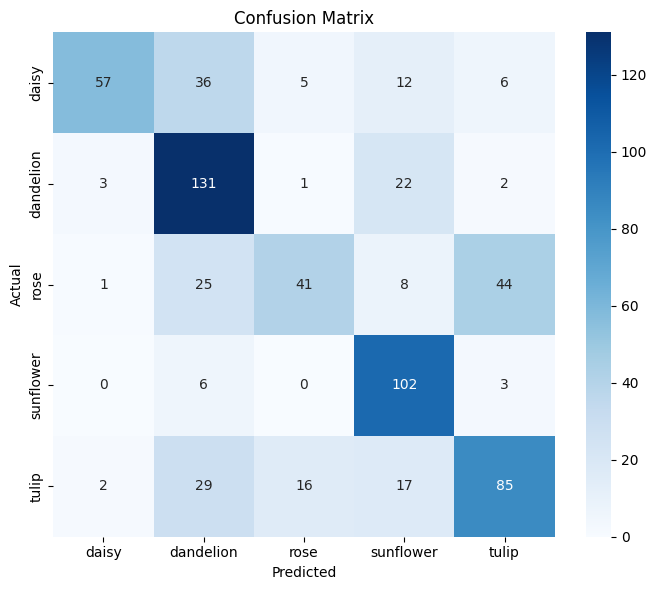

In [ ]:
# --- 2. Confusion Matrix heatmap ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

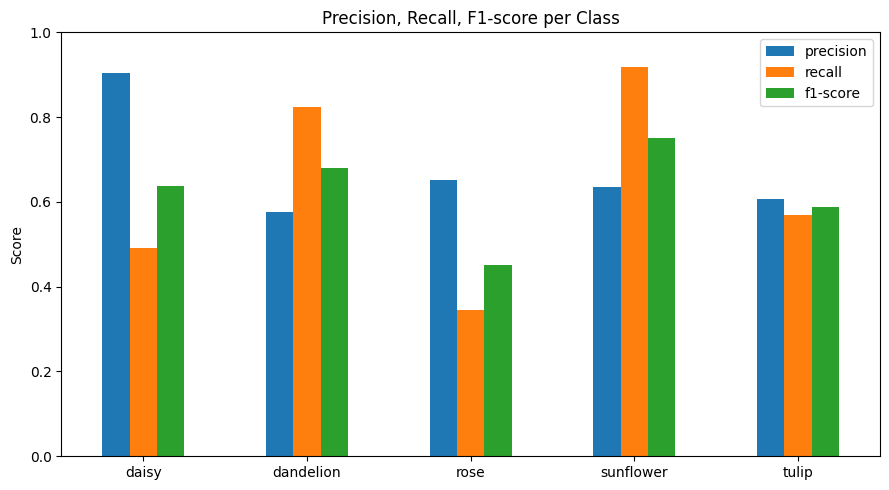

In [ ]:
# --- 3. Per-class Precision / Recall / F1 bar chart ---
metrics_df = report_df.loc[class_labels, ["precision", "recall", "f1-score"]]
metrics_df.plot(kind="bar", figsize=(9, 5))
plt.title("Precision, Recall, F1-score per Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

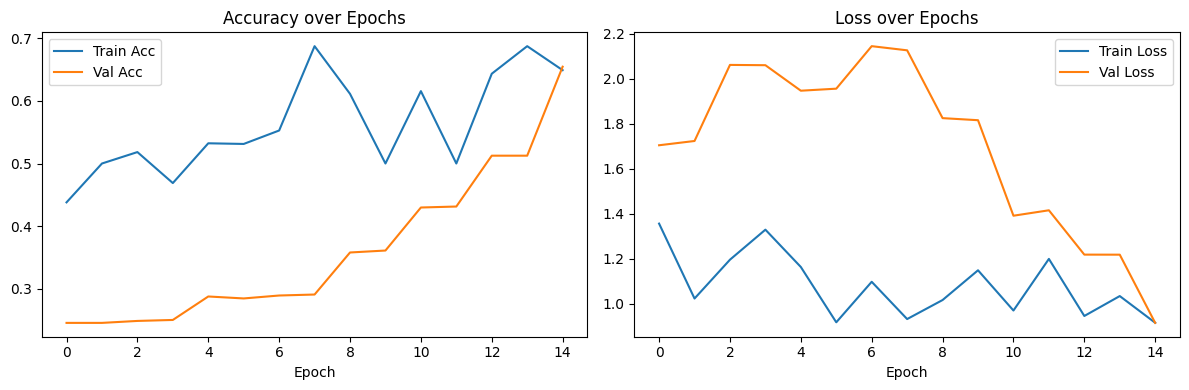


Overall Test Accuracy: 63.61%


In [ ]:
# --- 4. Training accuracy/loss curves (from history) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print(f"\nOverall Test Accuracy: {report_dict['accuracy']*100:.2f}%")


In [5]:
####cnn for quality degradation data

Quality_path = "/content/drive/MyDrive/flower-dataset/quality_degradation"

# source_folder = "/content/drive/MyDrive/flower-dataset/quality_degradation"
destination_folder = "/content/drive/MyDrive/flower-dataset/quality_degradation_split"


In [ ]:
import os
import random
import shutil

source_folder = "/content/drive/MyDrive/flower-dataset/quality_degradation"
destination_folder = "/content/drive/MyDrive/flower-dataset/quality_degradation_split"

train_ratio = 0.7
validation_ratio = 0.15
test_ratio = 0.15

random.seed(42)

# Create main folders
for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(destination_folder, split), exist_ok=True)

for flower in os.listdir(source_folder):

    flower_path = os.path.join(source_folder, flower)

    if not os.path.isdir(flower_path):
        continue

    # Create class folders
    os.makedirs(os.path.join(destination_folder, "train", flower), exist_ok=True)
    os.makedirs(os.path.join(destination_folder, "validation", flower), exist_ok=True)
    os.makedirs(os.path.join(destination_folder, "test", flower), exist_ok=True)

    images = os.listdir(flower_path)

    random.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)
    validation_end = train_end + int(total * validation_ratio)

    train_images = images[:train_end]
    validation_images = images[train_end:validation_end]
    test_images = images[validation_end:]

    for img in train_images:
        shutil.copy(
            os.path.join(flower_path, img),
            os.path.join(destination_folder, "train", flower, img)
        )

    for img in validation_images:
        shutil.copy(
            os.path.join(flower_path, img),
            os.path.join(destination_folder, "validation", flower, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(flower_path, img),
            os.path.join(destination_folder, "test", flower, img)
        )

print("Quality dataset split completed!")


TRAIN SET
train -> sunflower -> 7721658400_0dec46d225.jpg


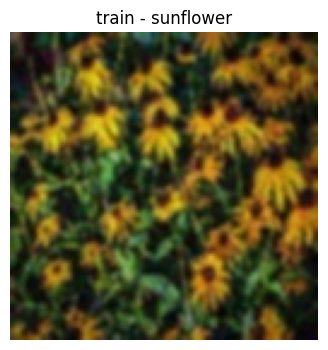

train -> tulip -> 14087425312_2b5846b570_n.jpg


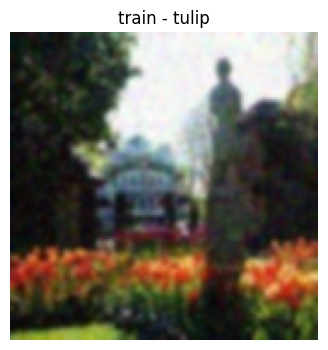

train -> rose -> 9159362388_c6f4cf3812_n.jpg


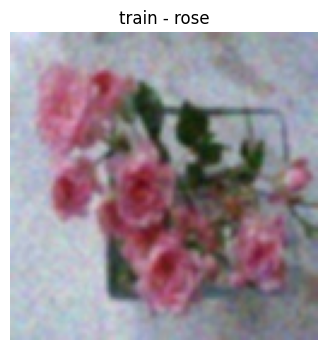

train -> dandelion -> 6918170172_3215766bf4_m.jpg


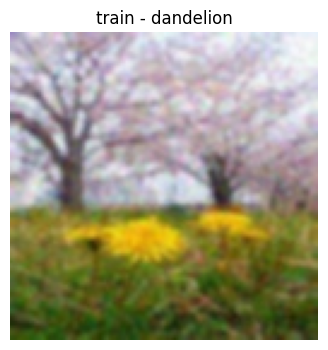

train -> daisy -> 6529588249_d9cbe68aab_n.jpg


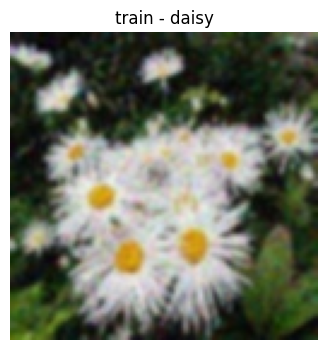


VALIDATION SET
validation -> sunflower -> 4872892690_52dc25b0b4.jpg


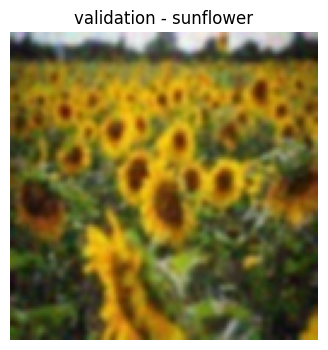

validation -> tulip -> 16751015081_af2ef77c9a_n.jpg


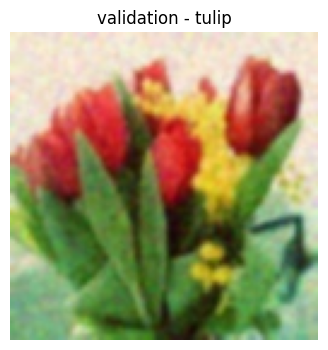

validation -> rose -> 14127110749_624f5bfde6_n.jpg


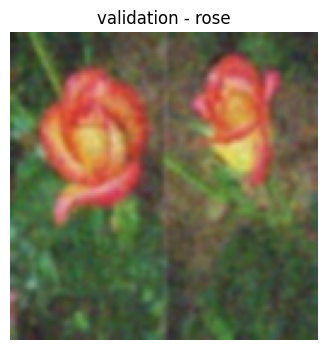

validation -> dandelion -> 7315832212_b0ceeb8de8_n.jpg


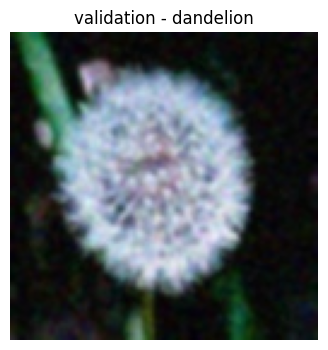

validation -> daisy -> 18203367608_07a04e98a4_n.jpg


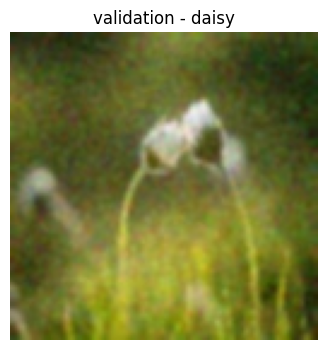


TEST SET
test -> sunflower -> 7176729016_d73ff2211e.jpg


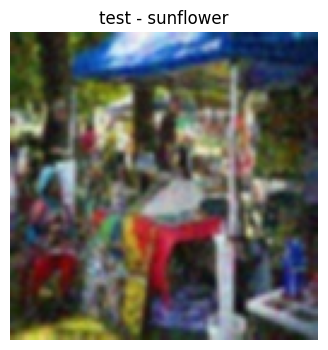

test -> tulip -> 9947374414_fdf1d0861c_n.jpg


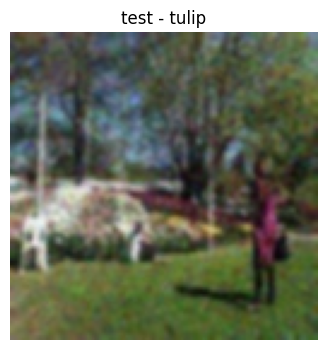

test -> rose -> 16209331331_343c899d38.jpg


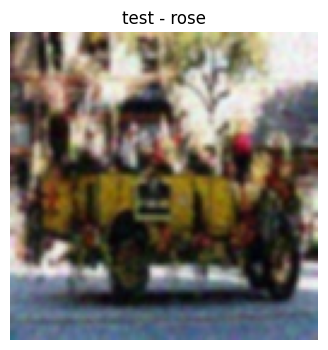

test -> dandelion -> 10828951106_c3cd47983f.jpg


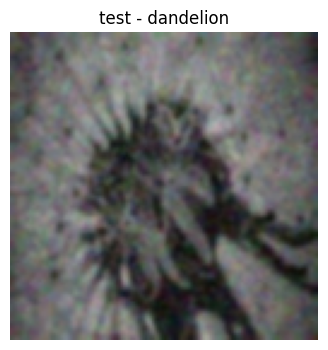

test -> daisy -> 34554334542_7d8f68a75c_n.jpg


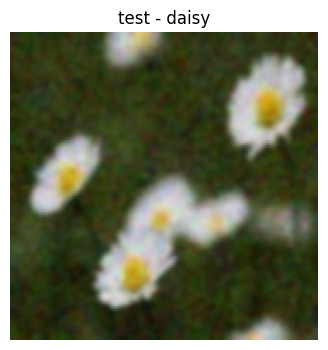

In [10]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split"

for split in ["train", "validation", "test"]:

    print(f"\n{'='*50}")
    print(f"{split.upper()} SET")
    print(f"{'='*50}")

    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls) ## split_class combine with the train

        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path) ## for train img

        if len(images) == 0:
            continue

        first_img = images[0]

        img_path = os.path.join(class_path, first_img)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print(f"{split} -> {cls} -> {first_img}")

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(f"{split} - {cls}")
        plt.axis("off")
        plt.show()

In [20]:
import os

dataset_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split"

for split in ["train", "validation", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls)

        if os.path.isdir(class_path):

            count = len(os.listdir(class_path))

            print(f"{cls}: {count}")

            total += count

    print("Total:", total)


TRAIN
sunflower: 609
tulip: 823
rose: 608
dandelion: 949
daisy: 586
Total: 3575

VALIDATION
sunflower: 170
tulip: 228
rose: 156
dandelion: 295
daisy: 138
Total: 987

TEST
sunflower: 165
tulip: 230
rose: 154
dandelion: 293
daisy: 151
Total: 993


In [12]:
train_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/train"

val_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/validation"

test_path = "/content/drive/MyDrive/flower-dataset/quality_degradation_split/test"

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # change to match your resized images, e.g. (224, 224)
BATCH_SIZE = 32

# Rescale for train/val/test. Add augmentation only on train if you want.
# train_datagen = ImageDataGenerator(rescale=1.0/255)

## data augumentation for training so it will improve the result
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen   = ImageDataGenerator(rescale=1.0/255)
test_datagen  = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # use 'binary' if only 2 classes
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # keep order for evaluation
)

# Sanity checks — run these before training
print("Train samples:", train_generator.samples, "| Classes:", train_generator.class_indices)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 3575 images belonging to 5 classes.
Found 987 images belonging to 5 classes.
Found 993 images belonging to 5 classes.
Train samples: 3575 | Classes: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Val samples: 987
Test samples: 993


In [24]:
print(train_generator.class_indices)

num_classes = len(train_generator.class_indices)

print("Number of classes:", num_classes)

{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Number of classes: 5


In [25]:
## --- CNN model ---
import numpy as np
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Better than Flatten()
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=15
)

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 1264s 11s/step - accuracy: 0.4485 - loss: 1.3432 - val_accuracy: 0.3000 - val_loss: 1.8616
Epoch 2/15
  1/111 ━━━━━━━━━━━━━━━━━━━━ 11:37 6s/step - accuracy: 0.3750 - loss: 1.3339

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 336ms/step - accuracy: 0.3750 - loss: 1.3339 - val_accuracy: 0.3000 - val_loss: 1.8670
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 680s 6s/step - accuracy: 0.5128 - loss: 1.1993 - val_accuracy: 0.2937 - val_loss: 2.1355
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 691ms/step - accuracy: 0.5312 - loss: 1.3589 - val_accuracy: 0.3010 - val_loss: 2.1346
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 670s 6s/step - accuracy: 0.5315 - loss: 1.1505 - val_accuracy: 0.3281 - val_loss: 2.2246
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 46s 372ms/step - accuracy: 0.3438 - loss: 1.3419 - val_accuracy: 0.3229 - val_loss: 2.2826
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 674s 6s/step - accuracy: 0.5687 - loss: 1.0875 - val_accuracy: 0.3281 - val_loss: 2.2103
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 80s 690ms/step - accuracy: 0.6250 - loss: 0.8848 - val_accuracy: 0.3323 - val_loss: 2.2069
Epoch 9/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 717s 6s/step - accuracy: 0.5758 - loss: 1.0646 - val_accurac

In [ ]:
# =====================================
# Save CNN Results to CSV
# =====================================

import pandas as pd
import os

# Replace these with your actual CNN accuracies
acc_original = 68.75       # CNN V1 Accuracy
# acc_quality = 0.00        # CNN V2 Accuracy
# acc_illumination = 0.00   # CNN V3 Accuracy

# Create Results Dictionary
results = {
    "Original": acc_original,
    # "Quality Degradation": acc_quality,
    # "Illumination Variation": acc_illumination
}

# Create DataFrame
df = pd.DataFrame({
    "Dataset": list(results.keys()),
    "Accuracy (%)": list(results.values())
})

# Calculate Change from Original
original_acc = acc_original

df["Accuracy Change (%)"] = (
    df["Accuracy (%)"] - original_acc
)

# File Path
csv_path = "/content/drive/MyDrive/flower-dataset/CNN_results.csv"

# Remove old file if it exists
if os.path.exists(csv_path):
    os.remove(csv_path)

# Save new CSV
df.to_csv(
    csv_path,
    index=False
)

print("CNN CSV Updated Successfully!\n")
print(df)

CNN CSV Updated Successfully!

    Dataset  Accuracy (%)  Accuracy Change (%)
0  Original         68.75                  0.0


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "VGG16",
        "MobileNetV2",
        "ResNet50"
    ],
    "Original Accuracy (%)": [
        46.30,
        68.75,
        85.40,
        86.69,
        54.00
    ]
})

print(comparison_df)

comparison_df.to_csv(
    "/content/drive/MyDrive/flower-dataset/Final_Comparison_Table.csv",
    index=False
)

         Model  Original Accuracy (%)
0          ANN                  46.30
1          CNN                  68.75
2        VGG16                  85.40
3  MobileNetV2                  86.69
4     ResNet50                  54.00
